In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from pgmpy.models import BayesianNetwork
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination

import skfuzzy as fuzz
import skfuzzy.control as ctrl
import warnings
warnings.filterwarnings('ignore')

c:\Users\hp\.conda\envs\traffic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

# Show all columns and prevent line breaks in DataFrame output
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)


In [3]:
df = pd.read_csv('Traffic_Accident.csv')  
df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [ ]:
# Basic Cleaning
df.dropna(subset=['Weather', 'Road_Condition', 'Driver_Alcohol', 'Accident', 'Speed_Limit'], inplace=True)

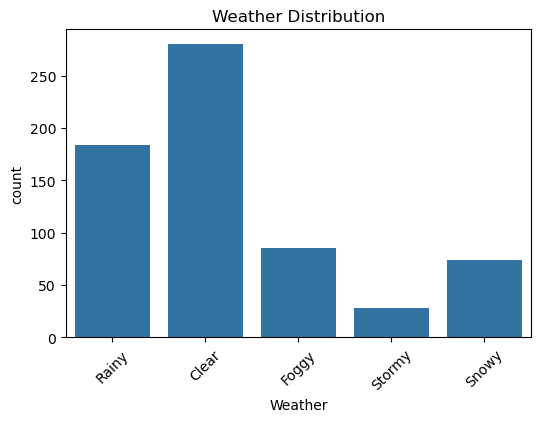

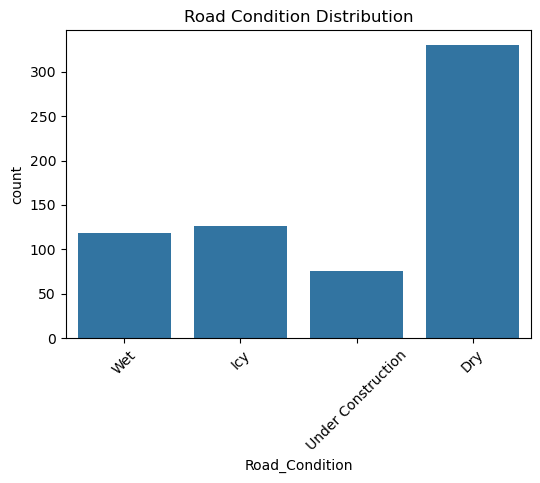

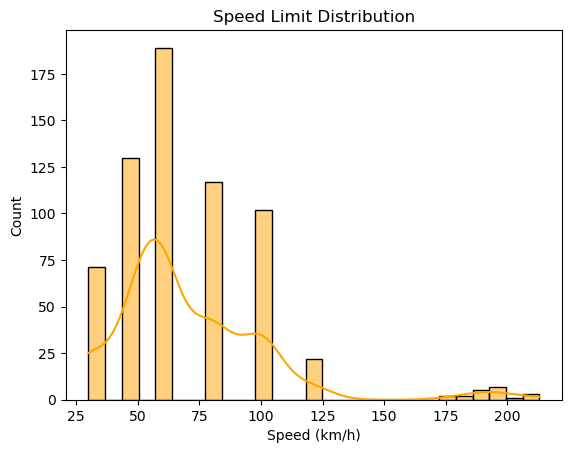

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


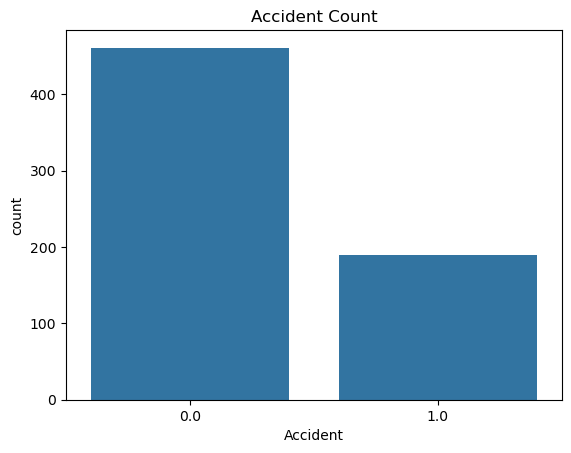

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Weather')
plt.title("Weather Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Road_Condition')
plt.title("Road Condition Distribution")
plt.xticks(rotation=45)
plt.show()


sns.histplot(df['Speed_Limit'], kde=True, color='orange')
plt.title("Speed Limit Distribution")
plt.xlabel("Speed (km/h)")
plt.show()

sns.countplot(data=df, x='Accident')
plt.title("Accident Count")
plt.show()

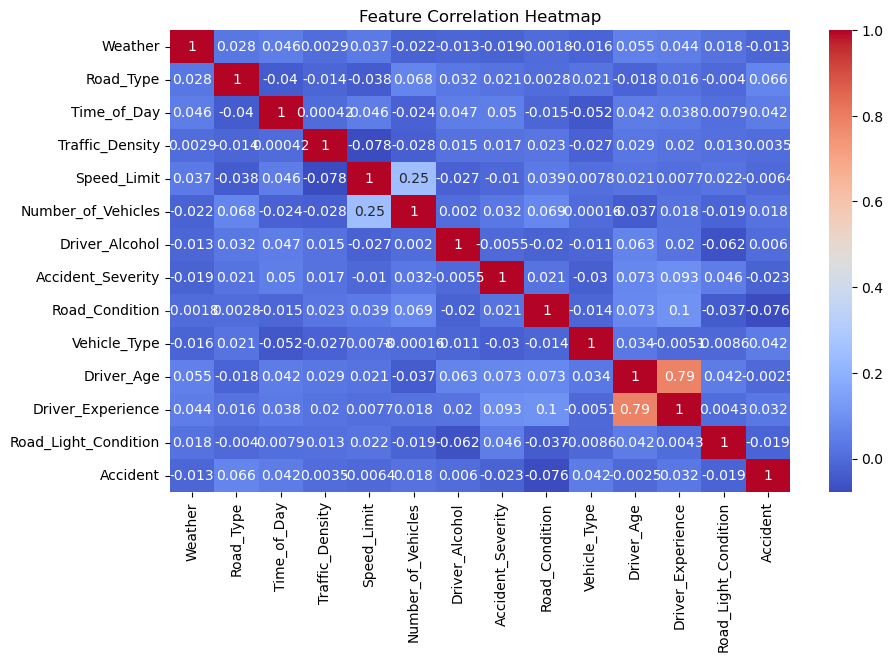

In [6]:
encoded_df = df.copy()
le = LabelEncoder()
for col in encoded_df.columns:
    encoded_df[col] = le.fit_transform(encoded_df[col])

plt.figure(figsize=(10, 6))
sns.heatmap(encoded_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Weather': 'N', 'Road_Type': 'N', 'Time_of_Day': 'N', 'Traffic_Density': 'N', 'Speed_Limit': 'N', 'Number_of_Vehicles': 'N', 'Driver_Alcohol': 'N', 'Accident_Severity': 'N', 'Road_Condition': 'N', 'Vehicle_Type': 'N', 'Driver_Age': 'N', 'Driver_Experience': 'N', 'Road_Light_Condition': 'N', 'Accident': 'N'}



Top 5 highest Accident risk cases:
     Weather  Road_Type  Time_of_Day  Traffic_Density  Speed_Limit  Number_of_Vehicles  Driver_Alcohol  Accident_Severity  Road_Condition  Vehicle_Type  Driver_Age  Driver_Experience  Road_Light_Condition  Accident  Accident_Prob_No  Accident_Prob_Yes
6          1          1            0              0.0         60.0                 4.0             0.0                  1               0             3        27.0               26.0                     1       1.0               0.0                1.0
7          2          0            0              0.0         60.0                 4.0             0.0                  1               0             1        29.0               22.0                     0       1.0               0.0                1.0
11         0          2            3              2.0        100.0                 5.0             0.0                  1               0             2        47.0               38.0                     0    

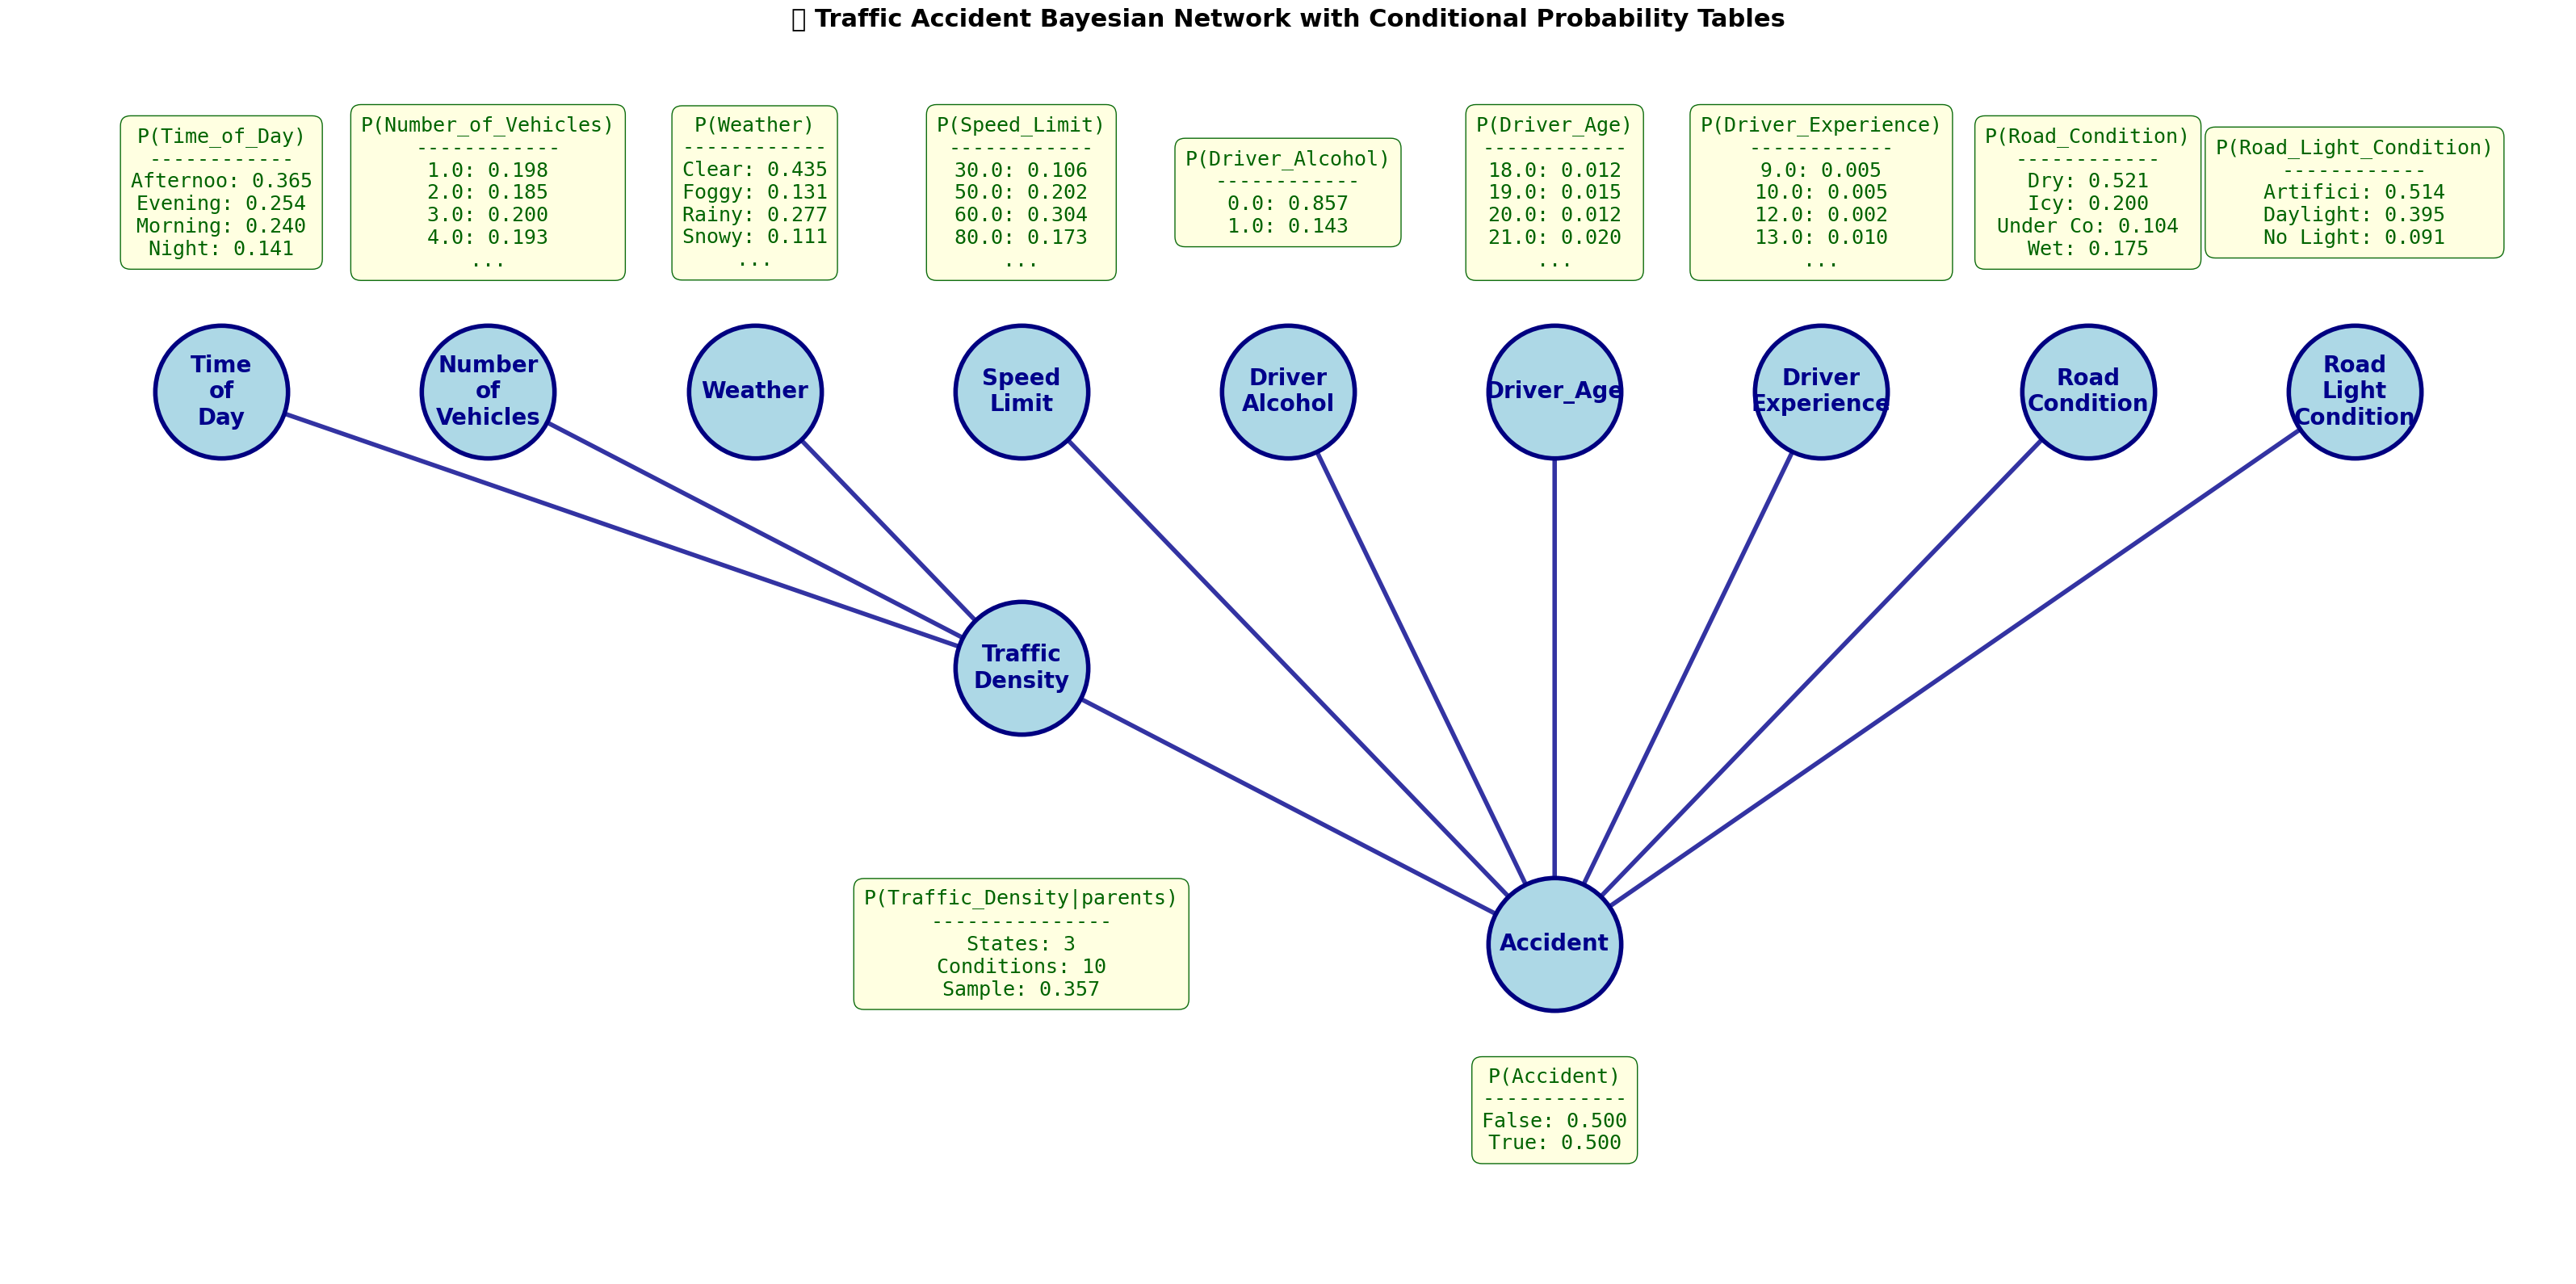


BAYESIAN NETWORK STRUCTURE
Nodes: ['Time_of_Day', 'Traffic_Density', 'Accident', 'Number_of_Vehicles', 'Weather', 'Speed_Limit', 'Driver_Alcohol', 'Driver_Age', 'Driver_Experience', 'Road_Condition', 'Road_Light_Condition']
Edges: [('Time_of_Day', 'Traffic_Density'), ('Traffic_Density', 'Accident'), ('Number_of_Vehicles', 'Traffic_Density'), ('Weather', 'Traffic_Density'), ('Speed_Limit', 'Accident'), ('Driver_Alcohol', 'Accident'), ('Driver_Age', 'Accident'), ('Driver_Experience', 'Accident'), ('Road_Condition', 'Accident'), ('Road_Light_Condition', 'Accident')]
Number of CPDs: 11

SAMPLE CPD DETAILS

CPD 1: Time_of_Day
Evidence variables: []
Cardinality: [4]

CPD 2: Traffic_Density
Evidence variables: ['Weather', 'Time_of_Day', 'Number_of_Vehicles']
Cardinality: [ 3 10  4  5]

CPD 3: Number_of_Vehicles
Evidence variables: []
Cardinality: [10]


In [7]:
# 🤖 Bayesian Belief Network
# -----------------------------
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 📥 Step 1: Load Dataset
df = pd.read_csv('Traffic_Accident.csv')

# 👀 Step 2: Drop missing values
df.dropna(inplace=True)

# 🏷️ Step 3: Encode categorical columns
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Step 4: Define Bayesian Network Structure
model = DiscreteBayesianNetwork([
    ('Time_of_Day', 'Traffic_Density'),
    ('Number_of_Vehicles', 'Traffic_Density'),
    ('Weather', 'Traffic_Density'),
    ('Speed_Limit', 'Accident'),
    ('Driver_Alcohol', 'Accident'),
    ('Driver_Age', 'Accident'),
    ('Driver_Experience', 'Accident'),
    ('Road_Condition', 'Accident'),
    ('Road_Light_Condition', 'Accident'),
    ('Traffic_Density', 'Accident')
])

# 🔁 Step 5: Train the model
model.fit(df, estimator=MaximumLikelihoodEstimator)

# 🔍 Step 6: Inference
infer = VariableElimination(model)

# 🎯 Step 7: Predict Accident probability
results = []
for _, row in df.iterrows():
    evidence = {
        'Weather': row['Weather'],
        'Time_of_Day': row['Time_of_Day'],
        'Traffic_Density': row['Traffic_Density'],
        'Speed_Limit': row['Speed_Limit'],
        'Number_of_Vehicles': row['Number_of_Vehicles'],
        'Driver_Alcohol': row['Driver_Alcohol'],
        'Road_Condition': row['Road_Condition'],
        'Driver_Age': row['Driver_Age'],
        'Driver_Experience': row['Driver_Experience'],
        'Road_Light_Condition': row['Road_Light_Condition'],
    }
    q = infer.query(variables=['Accident'], evidence=evidence)
    results.append(q.values)

# 📊 Step 8: Store results
df['Accident_Prob_No'] = [float(r[0]) for r in results]
df['Accident_Prob_Yes'] = [float(r[1]) for r in results]

# 🔁 Step 9: Decode Accident labels
if 'Accident' in label_encoders:
    df['Accident_Label'] = label_encoders['Accident'].inverse_transform(df['Accident'])

# ✅ Step 10: Show top risky predictions
print("\nTop 5 highest Accident risk cases:")
print(df.sort_values('Accident_Prob_Yes', ascending=False).head())

# 📌 Step 11: Create improved network visualization
G = nx.DiGraph()
G.add_edges_from(model.edges())

# Improved manual positioning with better spacing
pos = {
    # Top layer - independent variables (more spread out)
    'Time_of_Day': (-6, 3),
    'Number_of_Vehicles': (-3.5, 3),
    'Weather': (-1, 3),
    'Speed_Limit': (1.5, 3),
    'Driver_Alcohol': (4, 3),
    'Driver_Age': (6.5, 3),
    'Driver_Experience': (9, 3),
    'Road_Condition': (11.5, 3),
    'Road_Light_Condition': (14, 3),
    # Middle layer
    'Traffic_Density': (1.5, 0.5),
    # Bottom layer - target variable
    'Accident': (6.5, -2)
}

# 📌 Step 12: Improved CPT formatting function
def format_cpd_table(cpd, max_rows=4):
    """Format CPD table with better error handling and cleaner output"""
    var = cpd.variable
    
    try:
        # Special handling for Accident node - show True/False probabilities
        if var == 'Accident':
            lines = [f"P({var})"]
            lines.append("-" * 12)
            probs = cpd.values.flatten()
            lines.append(f"False: {probs[0]:.3f}")
            lines.append(f"True: {probs[1]:.3f}")
            return "\n".join(lines)
        
        # Get state names for the variable
        if hasattr(cpd, 'state_names') and var in cpd.state_names:
            var_states = cpd.state_names[var]
        else:
            var_states = [f"State_{i}" for i in range(len(cpd.values))]
        
        evidence_vars = cpd.get_evidence()
        
        # Root node (no parents)
        if len(evidence_vars) == 0:
            probs = cpd.values.flatten()
            lines = [f"P({var})"]
            lines.append("-" * 12)
            
            # Try to decode states if we have label encoders
            for i, p in enumerate(probs[:max_rows]):
                if var in label_encoders:
                    try:
                        # Get original label
                        original_label = label_encoders[var].inverse_transform([i])[0]
                        state_name = str(original_label)[:8]  # Truncate long names
                    except:
                        state_name = f"S{i}"
                else:
                    state_name = var_states[i] if i < len(var_states) else f"S{i}"
                lines.append(f"{state_name}: {p:.3f}")
            if len(probs) > max_rows:
                lines.append("...")
            return "\n".join(lines)
        
        # Nodes with parents - show sample conditional probabilities
        lines = [f"P({var}|parents)"]
        lines.append("-" * 15)
        
        # Get some sample probabilities
        values = cpd.values
        if values.ndim == 1:
            for i, p in enumerate(values[:max_rows]):
                if var in label_encoders:
                    try:
                        state_name = str(label_encoders[var].inverse_transform([i])[0])[:6]
                    except:
                        state_name = f"S{i}"
                else:
                    state_name = f"S{i}"
                lines.append(f"{state_name}: {p:.3f}")
        else:
            # For multi-dimensional arrays, show structure
            flat_values = values.flatten()
            lines.append(f"States: {values.shape[0]}")
            lines.append(f"Conditions: {values.shape[1] if values.ndim > 1 else 1}")
            lines.append(f"Sample: {flat_values[0]:.3f}")
        
        return "\n".join(lines)
        
    except Exception as e:
        return f"CPT for {var}\nError in formatting"

# Create the visualization with larger figure size
plt.figure(figsize=(32, 16))  

# Draw nodes with better styling and larger size
nx.draw_networkx_nodes(G, pos,
                       node_size=14000,  # Even larger nodes
                       node_color='lightblue',
                       edgecolors='navy',
                       linewidths=4)    # Thicker borders

# Draw edges with improved styling and better visibility
nx.draw_networkx_edges(G, pos,
                       edge_color='darkblue',
                       arrows=True,
                       arrowsize=40,  # Even larger arrows
                       width=4,       # Much thicker edges
                       arrowstyle='->',
                       alpha=0.8)

# Function to wrap text for better fitting in circles
def wrap_text(text, max_length=10):
    if len(text) <= max_length:
        return text
    # Split at underscores and wrap
    parts = text.split('_')
    if len(parts) > 1:
        return '\n'.join(parts)
    return text

# Draw node labels with better font sizing and wrapping
labels = {node: wrap_text(node, 10) for node in G.nodes()}
nx.draw_networkx_labels(G, pos,
                        labels=labels,
                        font_size=20,    # Much larger font size for node labels
                        font_weight='bold',
                        font_color='darkblue')

# Add CPT tables with improved positioning
cpd_positions = {
    'Time_of_Day': (-6, 4.8),
    'Number_of_Vehicles': (-3.5, 4.8),
    'Weather': (-1, 4.8),
    'Speed_Limit': (1.5, 4.8),
    'Driver_Alcohol': (4, 4.8),
    'Driver_Age': (6.5, 4.8),
    'Driver_Experience': (9, 4.8),
    'Road_Condition': (11.5, 4.8),
    'Road_Light_Condition': (14, 4.8),
    'Traffic_Density': (1.5, -2),  # Position below the Traffic_Density node
    'Accident': (6.5, -3.5)
}

for cpd in model.get_cpds():
    var = cpd.variable
    try:
        table_text = format_cpd_table(cpd, max_rows=4)
        
        if var in cpd_positions:
            x, y = cpd_positions[var]
        else:
            x, y = pos[var]
            y += 1.5  # Default offset
        
        plt.text(
            x, y,
            table_text,
            fontsize=18,     
            fontfamily='monospace',
            color='darkgreen',
            verticalalignment='center',
            horizontalalignment='center',
            bbox=dict(facecolor='lightyellow', 
                     alpha=0.95,     # More opaque background
                     edgecolor='darkgreen', 
                     boxstyle='round,pad=0.5'),  # More padding
            clip_on=False
        )
    except Exception as e:
        print(f"Error processing CPD for {var}: {e}")

# Improve plot appearance
plt.title("🚗 Traffic Accident Bayesian Network with Conditional Probability Tables", 
          fontsize=22, fontweight='bold', pad=30)  # Much larger title
plt.axis('off')

# Set axis limits to ensure everything is visible with better spacing
plt.xlim(-8, 16)
plt.ylim(-5, 6)

plt.tight_layout()
plt.show()

# Additional analysis - show model structure
print("\n" + "="*50)
print("BAYESIAN NETWORK STRUCTURE")
print("="*50)
print(f"Nodes: {list(G.nodes())}")
print(f"Edges: {list(G.edges())}")
print(f"Number of CPDs: {len(model.get_cpds())}")

# Show sample CPD details
print("\n" + "="*50)
print("SAMPLE CPD DETAILS")
print("="*50)
for i, cpd in enumerate(model.get_cpds()[:3]):  # Show first 3 CPDs
    print(f"\nCPD {i+1}: {cpd.variable}")
    print(f"Evidence variables: {cpd.get_evidence()}")
    print(f"Cardinality: {cpd.cardinality}")




Decision Tree Accuracy: 65.43%


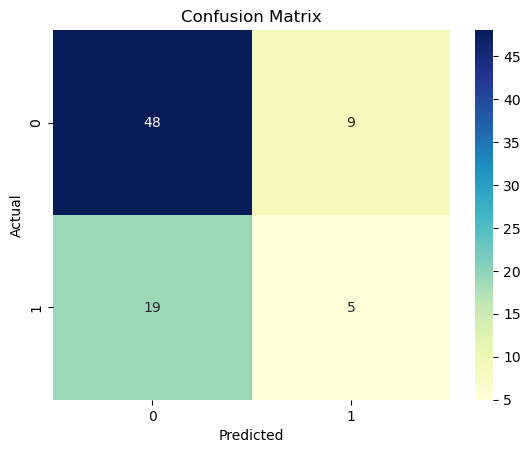

In [8]:
#ML Model - Decision Tree
X = df[['Weather', 'Road_Condition', 'Driver_Alcohol', 'Speed_Limit']]
y = df['Accident']

for col in X.columns:
    X[col] = le.fit_transform(X[col])
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
y_pred = model_dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nDecision Tree Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
sample = df.iloc[0]  # first row


Calculated Risk Score: 83.11111111111109


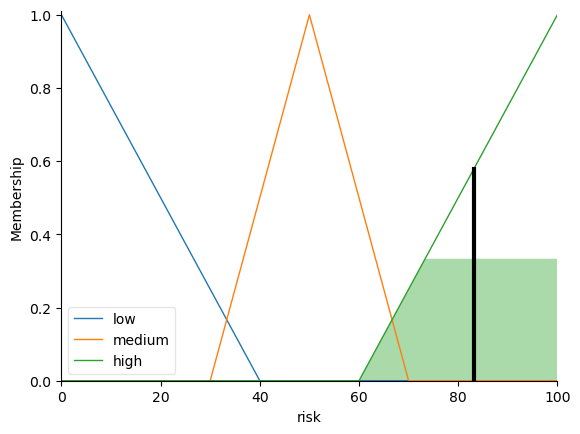

In [10]:
# 🌫️ Fuzzy Logic System

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define fuzzy variables
speed = ctrl.Antecedent(np.arange(0, 201, 1), 'speed')
traffic = ctrl.Antecedent(np.arange(0, 4, 1), 'traffic')  
vehicles = ctrl.Antecedent(np.arange(0, 21, 1), 'vehicles')
age = ctrl.Antecedent(np.arange(16, 81, 1), 'age')
experience = ctrl.Antecedent(np.arange(0, 66, 1), 'experience')
risk = ctrl.Consequent(np.arange(0, 101, 1), 'risk')



# Membership functions
speed['poor'] = fuzz.trimf(speed.universe, [0, 0, 60])
speed['average'] = fuzz.trimf(speed.universe, [40, 100, 150])
speed['good'] = fuzz.trimf(speed.universe, [120, 200, 200])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 1])
traffic['medium'] = fuzz.trimf(traffic.universe, [0.5, 1.5, 2.5])
traffic['high'] = fuzz.trimf(traffic.universe, [2, 3, 3])

vehicles['few'] = fuzz.trimf(vehicles.universe, [0, 0, 5])
vehicles['moderate'] = fuzz.trimf(vehicles.universe, [3, 7, 12])
vehicles['many'] = fuzz.trimf(vehicles.universe, [10, 20, 20])

age['young'] = fuzz.trimf(age.universe, [16, 20, 30])
age['middle'] = fuzz.trimf(age.universe, [25, 40, 55])
age['old'] = fuzz.trimf(age.universe, [50, 80, 80])

experience['low'] = fuzz.trimf(experience.universe, [0, 0, 15])
experience['medium'] = fuzz.trimf(experience.universe, [10, 25, 40])
experience['high'] = fuzz.trimf(experience.universe, [35, 65, 65])

risk['low'] = fuzz.trimf(risk.universe, [0, 0, 40])
risk['medium'] = fuzz.trimf(risk.universe, [30, 50, 70])
risk['high'] = fuzz.trimf(risk.universe, [60, 100, 100])

# Define rules
rules = [
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['old'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['old'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['few'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['middle'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['middle'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['old'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['old'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['low'] & vehicles['many'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['middle'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['middle'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['old'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['old'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['few'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['low'], risk['medium']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['medium'], risk['low']),
    ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['low'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['medium'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['young'] & experience['medium'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['few'] & age['old'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['young'] & experience['medium'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['high'], risk['low']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['poor'] & traffic['high'] & vehicles['many'] & age['old'] & experience['high'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['low'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['medium'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['high'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['old'] & experience['low'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['old'] & experience['medium'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['few'] & age['old'] & experience['high'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['low'], risk['medium']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['high'], risk['low']),
ctrl.Rule(speed['average'] & traffic['low'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),

    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['few'] & age['old'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['average'] & traffic['high'] & vehicles['many'] & age['old'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['middle'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['few'] & age['old'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['moderate'] & age['old'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['middle'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['low'] & vehicles['many'] & age['old'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['middle'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['few'] & age['old'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['young'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['old'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['old'] & experience['medium'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['old'] & experience['high'], risk['medium']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['moderate'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['young'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['medium'] & vehicles['many'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['young'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['few'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['young'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['moderate'] & age['old'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['young'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['young'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['young'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['middle'] & experience['high'], risk['low']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['old'] & experience['low'], risk['high']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['old'] & experience['medium'], risk['medium']),
    ctrl.Rule(speed['good'] & traffic['high'] & vehicles['many'] & age['old'] & experience['high'], risk['low']),



]


# Create control system
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

risk_sim.input['speed'] = 60
risk_sim.input['traffic'] = 3
risk_sim.input['vehicles'] = 20
risk_sim.input['age'] = 30
risk_sim.input['experience'] = 7


risk_sim.compute()
print("Calculated Risk Score:", risk_sim.output['risk'])

risk.view(sim=risk_sim)






In [11]:
import numpy as np
import skfuzzy as fuzz

# Define your fuzzy universe
x_risk = np.arange(0, 101, 1)

# Define membership functions (same as your plot)
low = fuzz.trimf(x_risk, [0, 0, 40])
medium = fuzz.trimf(x_risk, [30, 50, 70])
high = fuzz.trimf(x_risk, [60, 100, 100])

# Crisp output from fuzzy system
risk_score = 83.1111111111111

# Get membership values for that crisp score
mu_low = fuzz.interp_membership(x_risk, low, risk_score)
mu_medium = fuzz.interp_membership(x_risk, medium, risk_score)
mu_high = fuzz.interp_membership(x_risk, high, risk_score)

print(f"Low membership: {mu_low}")
print(f"Medium membership: {mu_medium}")
print(f"High membership: {mu_high}")


Low membership: 0.0
Medium membership: 0.0
High membership: 0.5777777777777775


In [12]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score

# SETTINGS
CSV_FILENAME = "Traffic_Accident.csv"
SAVE_DIR = "outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# LOAD DATA
if not os.path.exists(CSV_FILENAME):
    raise FileNotFoundError(f"{CSV_FILENAME} not found. Place it in the same folder.")

df = pd.read_csv(CSV_FILENAME)
print(f"✅ Loaded {CSV_FILENAME} | Shape = {df.shape}")


# FUZZY MEMBERSHIP FUNCTION
def triangular_membership(x, a, b, c):
    """Return triangular fuzzy membership values"""
    x = np.asarray(x, dtype=float)
    res = np.zeros_like(x, dtype=float)
    left = (x >= a) & (x <= b)
    res[left] = (x[left] - a) / (b - a + 1e-12)
    right = (x > b) & (x <= c)
    res[right] = (c - x[right]) / (c - b + 1e-12)
    return np.clip(res, 0.0, 1.0)


# CREATE FUZZY SETS FOR NUMERIC COLUMNS
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
memberships = {}
marginals = {}

for col in num_cols:
    vals = df[col].values.astype(float)
    p0 = np.nanmin(vals)
    p50 = np.nanpercentile(vals, 50)
    p100 = np.nanmax(vals)

    # Low
    low = triangular_membership(vals, p0, p0 + (p50 - p0)/2, p50)
    # Medium
    med = triangular_membership(vals, p0, p50, p100)
    # High
    high = triangular_membership(vals, p50, p100 - (p100 - p50)/2, p100)

    memb = np.vstack([low, med, high]).T
    memb /= memb.sum(axis=1, keepdims=True) + 1e-12

    memberships[col] = pd.DataFrame(memb, columns=[f'{col}_Low', f'{col}_Med', f'{col}_High'])
    marginals[col] = memberships[col].mean().rename(lambda s: s.replace(f"{col}_", ""))


# DISCRETIZE FOR MI ,Converts fuzzy membership back into discrete states:
discrete = pd.DataFrame(index=df.index)
for col, memb_df in memberships.items():
    discrete[col] = memb_df.values.argmax(axis=1)  # 0=Low, 1=Med, 2=High


# MUTUAL INFORMATION MATRIX , Mutual Information tells how much knowing A reduces uncertainty in B.
#If time_of_day strongly determines traffic_density, MI will be high.
cols = list(memberships.keys())
mi = pd.DataFrame(0.0, index=cols, columns=cols)
for i, a in enumerate(cols):
    for j, b in enumerate(cols):
        if i >= j:
            continue
        m = mutual_info_score(discrete[a], discrete[b])
        mi.loc[a, b] = m
        mi.loc[b, a] = m


# ENTROPY FUNCTION ,uncertainty in a distribution.
#If traffic_density is always Medium → entropy = 0 (no uncertainty).
def entropy(p):
    """Shannon entropy in bits"""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log2(p)) if p.size > 0 else 0.0


# SENSITIVITY MATRIX ,Sensitivity = MI / Entropy of child.
sensitivity = pd.DataFrame(0.0, index=cols, columns=cols)
for a in cols:
    for b in cols:
        if a == b:
            continue
        Iab = mi.loc[a, b]
        probs_b = list(marginals[b].values)
        Hb = entropy(probs_b)
        sensitivity.loc[a, b] = Iab / (Hb + 1e-12)

# Save CSV
sensitivity_file = f"{SAVE_DIR}/sensitivity_matrix.csv"
sensitivity.to_csv(sensitivity_file)
print(f"💾 Saved sensitivity matrix -> {sensitivity_file}")


# SHOW RESULTS
print("\n📊 FULL Sensitivity Matrix:")
print(sensitivity)

print("\n🔥 All Parent → Child Sensitivities sorted:")
s_flat = sensitivity.stack().reset_index()
s_flat.columns = ['Parent', 'Child', 'Sensitivity']
s_flat = s_flat.sort_values('Sensitivity', ascending=False)
print(s_flat.to_string(index=False))



✅ Loaded Traffic_Accident.csv | Shape = (840, 14)
💾 Saved sensitivity matrix -> outputs/sensitivity_matrix.csv

📊 FULL Sensitivity Matrix:
                    Traffic_Density  Speed_Limit  Number_of_Vehicles  Driver_Alcohol  Driver_Age  Driver_Experience  Accident
Traffic_Density            0.000000     0.001127            0.001330             0.0    0.001071           0.002215       0.0
Speed_Limit                0.002449     0.000000            0.053435             0.0    0.004571           0.005295       0.0
Number_of_Vehicles         0.002963     0.054826            0.000000             0.0    0.002354           0.002536       0.0
Driver_Alcohol             0.000000     0.000000            0.000000             0.0    0.000000           0.000000       0.0
Driver_Age                 0.003031     0.005952            0.002987             0.0    0.000000           0.377231       0.0
Driver_Experience          0.006215     0.006839            0.003193             0.0    0.374192         

In [13]:
#Combine fuzzy and BBN

import pandas as pd

# Example outputs from your system
P_accident_BBN = 0.5  # From BBN
mu_low = 0.0
mu_medium = 0.0
mu_high = 0.5777777777777775  # From fuzzy

# Put them in DataFrame
df = pd.DataFrame({
    'P_accident_BBN': [P_accident_BBN],
    'P_low_fuzzy': [mu_low],
    'P_medium_fuzzy': [mu_medium],
    'P_high_fuzzy': [mu_high]
})

# Use the *actual* fuzzy high membership value, not normalized
df['Combined_risk'] = df['P_accident_BBN'] * df['P_high_fuzzy']  #Combined Risk=0.5×0.577≈0.2885

print(df)




   P_accident_BBN  P_low_fuzzy  P_medium_fuzzy  P_high_fuzzy  Combined_risk
0             0.5          0.0             0.0      0.577778       0.288889


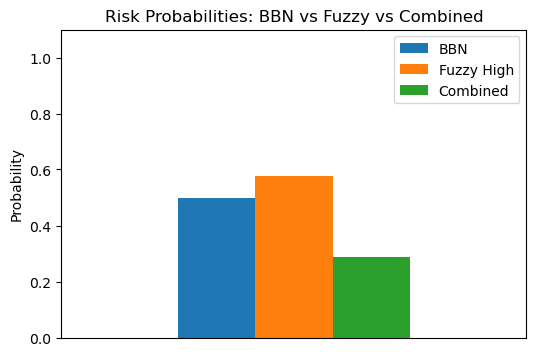

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Your example data
df = pd.DataFrame({
    'P_accident_BBN': [0.5],
    'P_high_fuzzy': [0.577778],
    'Combined_risk': [0.288889]
})

# Plot
df.plot(kind='bar', figsize=(6,4))
plt.title("Risk Probabilities: BBN vs Fuzzy vs Combined")
plt.ylabel("Probability")
plt.xticks([])   # This removes x-axis ticks/labels
plt.ylim(0, 1.1)
plt.legend(["BBN", "Fuzzy High", "Combined"])
plt.show()
